In [ ]:
!pip install -q torch torchvision torchaudio timm resnest

import os, zipfile, shutil, random
from google.colab import files
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
import timm
from tqdm import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

extract_path = "/content/dataset_raw"
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Find dataset folder
subdirs = os.listdir(extract_path)
if len(subdirs) == 1:
    dataset_root = os.path.join(extract_path, subdirs[0])
else:
    dataset_root = extract_path

print(f" --- Dataset extracted at: {dataset_root}")
print(" --- Subfolders:", os.listdir(dataset_root))

Saving vehi_cles.zip to vehi_cles.zip
 --- Dataset extracted at: /content/dataset_raw/vehi_cles
 --- Subfolders: ['Cars', 'Motorcycles']


In [ ]:
# Create train/val split
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

classes = os.listdir(dataset_root)
for cls in classes:
    cls_path = os.path.join(dataset_root, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("Train/Validation split created...")

Train/Validation split created...


In [ ]:

# Define transforms & loaders
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),          # Smaller image for faster training
    transforms.RandomHorizontalFlip(),      # Keep augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((128, 128)),          # Match smaller size for validation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=transform_train)
val_data = datasets.ImageFolder(val_dir, transform=transform_val)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

In [ ]:
# Base Model (ResNeSt)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = timm.create_model('resnest50d', pretrained=True, num_classes=2)
base_model = base_model.to(device)

warnings.filterwarnings("ignore", message="The secret `HF_TOKEN`")

#--- Freeze all layers except the final classification head
for param in base_model.parameters():
    param.requires_grad = False
for param in base_model.get_classifier().parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(base_model.parameters(), lr=0.001)

print("--- Training Base Model...")
for epoch in range(3):  # short training for demo
    base_model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = base_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluate base model
base_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = base_model(inputs)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

base_acc = 100 * correct / total
print(f"Base Model Accuracy: {base_acc:.2f}%")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

--- Training Base Model...


100%|██████████| 80/80 [10:12<00:00,  7.65s/it]


Epoch 1, Loss: 0.2200


100%|██████████| 80/80 [10:09<00:00,  7.61s/it]


Epoch 2, Loss: 0.0920


100%|██████████| 80/80 [10:11<00:00,  7.64s/it]


Epoch 3, Loss: 0.0911
Base Model Accuracy: 98.43%


In [ ]:
# Tuned Model
tuned_model = timm.create_model('resnest50d', pretrained=True, num_classes=2)
tuned_model = tuned_model.to(device)

# Freeze early layers for fine-tuning
for name, param in tuned_model.named_parameters():
    if "layer4" not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, tuned_model.parameters()), lr=0.0005)

print("...Training Tuned Model...")
for epoch in range(3):
    tuned_model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = tuned_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
# Evaluate tuned model
tuned_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = tuned_model(inputs)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

tuned_acc = 100 * correct / total
print(f"... Tuned Model Accuracy: {tuned_acc:.2f}% ...")

...Training Tuned Model...


100%|██████████| 80/80 [10:59<00:00,  8.25s/it]


Epoch 1, Loss: 0.1116


100%|██████████| 80/80 [10:59<00:00,  8.25s/it]


Epoch 2, Loss: 0.0382


100%|██████████| 80/80 [10:56<00:00,  8.20s/it]


Epoch 3, Loss: 0.0115
... Tuned Model Accuracy: 98.74% ...


In [ ]:
# K-Fold Cross-Validation + Overfitting Analysis + Summary
from torch.utils.data import Subset
from sklearn.model_selection import KFold

print("\n----- Starting 5-Fold Cross Validation on Tuned Model -----")

dataset = datasets.ImageFolder(train_dir, transform=transform_train)
num_classes = len(dataset.classes)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
fold_train_acc, fold_val_acc = [], []
fold_train_loss, fold_val_loss = [], []

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    acc = 100 * correct / total
    return running_loss / len(loader), acc, all_preds, all_labels

    # Perform 5-Fold Cross Validation
for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(len(dataset)))):
    print(f"\n----- Fold {fold+1}/5 -----")

    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    train_loader_cv = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader_cv = DataLoader(val_subset, batch_size=16, shuffle=False)

    # Load tuned model (new instance each fold)
    model = timm.create_model('resnest50d', pretrained=True, num_classes=num_classes)
    model = model.to(device)
    for name, param in model.named_parameters():
        if "layer4" not in name:
            param.requires_grad = False

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(1):  # same as before
        tr_loss, tr_acc = train_one_epoch(model, train_loader_cv, criterion, optimizer)
        val_loss, val_acc, preds, labels = evaluate(model, val_loader_cv, criterion)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)
        print(f"Epoch [{epoch+1}/1] | Train Acc: {tr_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    fold_train_acc.append(np.mean(train_accs))
    fold_val_acc.append(np.mean(val_accs))
    fold_train_loss.append(np.mean(train_losses))
    fold_val_loss.append(np.mean(val_losses))
    fold_results.append(np.mean(val_accs))

print("\n----- Cross Validation Results -----")
for i, acc in enumerate(fold_results):
    print(f"Fold {i+1}: {acc:.2f}%")

tuned_acc_mean = np.mean(fold_results)
tuned_acc_std = np.std(fold_results)


----- Starting 5-Fold Cross Validation on Tuned Model -----

----- Fold 1/5 -----
Epoch [1/1] | Train Acc: 94.69% | Val Acc: 98.04%

----- Fold 2/5 -----
Epoch [1/1] | Train Acc: 95.48% | Val Acc: 99.22%

----- Fold 3/5 -----
Epoch [1/1] | Train Acc: 95.38% | Val Acc: 99.21%

----- Fold 4/5 -----
Epoch [1/1] | Train Acc: 93.61% | Val Acc: 98.03%

----- Fold 5/5 -----
Epoch [1/1] | Train Acc: 95.87% | Val Acc: 98.82%

----- Cross Validation Results -----
Fold 1: 98.04%
Fold 2: 99.22%
Fold 3: 99.21%
Fold 4: 98.03%
Fold 5: 98.82%


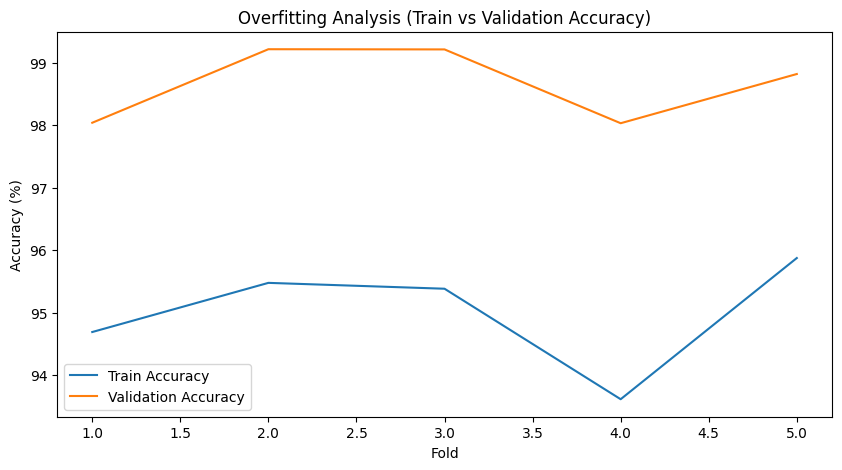

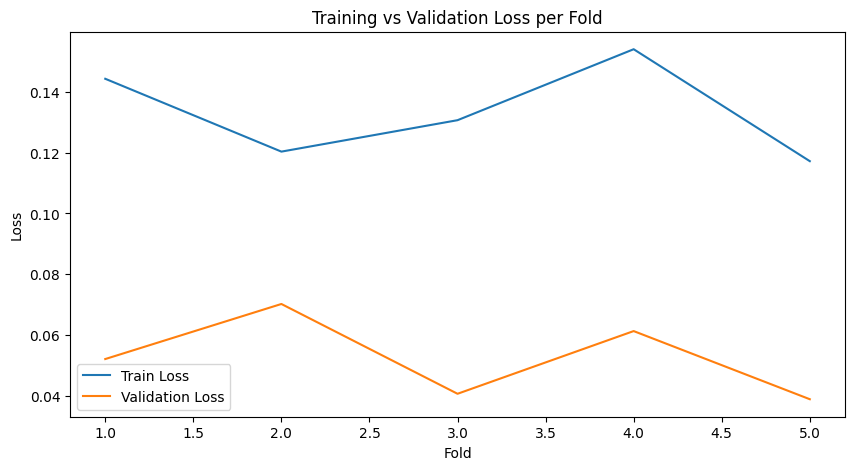

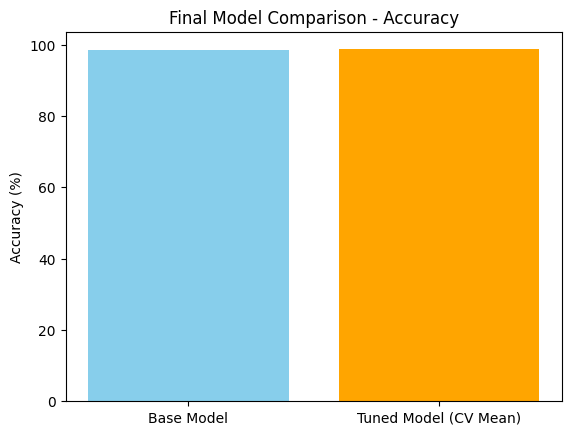

In [ ]:
# Overfitting & Model Comparison
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), fold_train_acc, label='Train Accuracy')
plt.plot(range(1, 6), fold_val_acc, label='Validation Accuracy')
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("Overfitting Analysis (Train vs Validation Accuracy)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), fold_train_loss, label='Train Loss')
plt.plot(range(1, 6), fold_val_loss, label='Validation Loss')
plt.xlabel("Fold")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss per Fold")
plt.legend()
plt.show()

plt.bar(["Base Model", "Tuned Model (CV Mean)"], [base_acc, tuned_acc_mean],
        color=["skyblue", "orange"])
plt.title("Final Model Comparison - Accuracy")
plt.ylabel("Accuracy (%)")
plt.show()

In [ ]:
# Overfitting Status + Final Summary
if np.mean(fold_train_acc) - np.mean(fold_val_acc) > 5:
    overfit_status = "--- Model shows signs of overfitting (train > validation >5%)"
else:
    overfit_status = "--- 02No significant overfitting detected"

print("\n---------------- FINAL SUMMARY ---------------")
print(f"Base Model Accuracy (Val):     {base_acc:.2f}%")
print(f"Tuned Model (CV Mean Acc):     {tuned_acc_mean:.2f}%")
print(f"Model Stability (Acc. StdDev): {tuned_acc_std:.3f}")
print(f"Overfitting Status: {overfit_status}")



---------------- FINAL SUMMARY ---------------
Base Model Accuracy (Val):     98.43%
Tuned Model (CV Mean Acc):     98.66%
Model Stability (Acc. StdDev): 0.533
Overfitting Status: --- 02No significant overfitting detected
